In [115]:
!pip install seaborn
!pip install scikit-learn
%pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 30.5 MB/s eta 0:00:000:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 30.6 MB/s eta 0:00:00m eta 0:00:010:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style("white")
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
print("Path to dataset files:", path)

Path to dataset files: /home/ben/.cache/kagglehub/datasets/maharshipandya/-spotify-tracks-dataset/versions/1


In [116]:
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

In [75]:
file_path = '/home/ben/.cache/kagglehub/datasets/maharshipandya/-spotify-tracks-dataset/versions/1/dataset.csv'
df = pd.read_csv(file_path)

In [76]:
pd.set_option('display.float_format', '{:.3f}'.format)
print(df.describe())

       Unnamed: 0  popularity  duration_ms  danceability     energy  \
count  114000.000  114000.000   114000.000    114000.000 114000.000   
mean    56999.500      33.239   228029.153         0.567      0.641   
std     32909.110      22.305   107297.713         0.174      0.252   
min         0.000       0.000        0.000         0.000      0.000   
25%     28499.750      17.000   174066.000         0.456      0.472   
50%     56999.500      35.000   212906.000         0.580      0.685   
75%     85499.250      50.000   261506.000         0.695      0.854   
max    113999.000     100.000  5237295.000         0.985      1.000   

             key   loudness       mode  speechiness  acousticness  \
count 114000.000 114000.000 114000.000   114000.000    114000.000   
mean       5.309     -8.259      0.638        0.085         0.315   
std        3.560      5.029      0.481        0.106         0.333   
min        0.000    -49.531      0.000        0.000         0.000   
25%        2.00

In [77]:
# Define reasonable duration thresholds (in milliseconds)
min_duration_ms = 30 * 1000      # 30 seconds
max_duration_ms = 10 * 60 * 1000  # 10 minutes

# Filter the dataset
df_clean = df[(df['duration_ms'] >= min_duration_ms) & (df['duration_ms'] <= max_duration_ms)].copy()

# Print summary of the filtering process
removed_tracks = len(df) - len(df_clean)
print(f"Removed {removed_tracks} anomalous tracks (shorter than 30 seconds or longer than 10 minutes).")
print(f"Updated dataset size: {len(df_clean)} tracks.")

Removed 620 anomalous tracks (shorter than 30 seconds or longer than 10 minutes).
Updated dataset size: 113380 tracks.


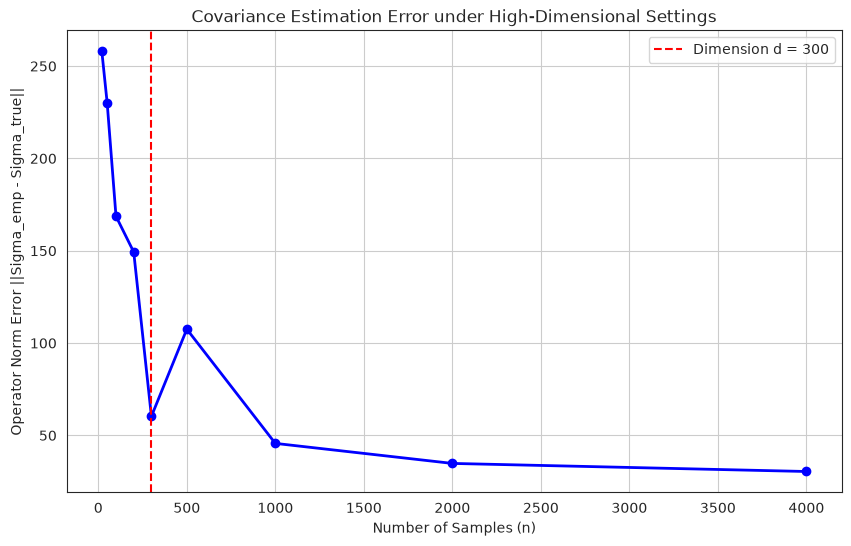

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Select continuous features from the pre-loaded dataframe
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'popularity']

df_clean = df[features].dropna()

# 2. Compute the baseline covariance matrix (10x10)
Sigma_base = df_clean.cov().to_numpy()

# 3. Inflate the dimension to d = 300 (high-dimensional phenomenon)
d = 300
Sigma_high = np.zeros((d, d))
Sigma_high[0:10, 0:10] = Sigma_base

# Add controlled noise to ensure the matrix is symmetric and positive definite
A = np.random.randn(d, d) * 0.1
Sigma_high = Sigma_high + np.dot(A, A.T)
np.fill_diagonal(Sigma_high, np.diagonal(Sigma_high) + 0.5)

# 4. Concentration bounds experiment - evaluate error as a function of sample size (n)
n_samples_range = [20, 50, 100, 200, 300, 500, 1000, 2000, 4000]
errors = []
mean = np.zeros(d)

for n in n_samples_range:
    # Sample n synthetic songs from the high-dimensional distribution
    X = np.random.multivariate_normal(mean, Sigma_high, size=n)
    
    # Compute the empirical covariance matrix from the sample
    Sigma_empirical = np.cov(X, rowvar=False)
    
    # Compute the estimation error using the operator norm (spectral norm)
    error = np.linalg.norm(Sigma_empirical - Sigma_high, ord=2)
    errors.append(error)

# 5. Plotting the graph
plt.figure(figsize=(10, 6))
plt.plot(n_samples_range, errors, marker='o', color='b', linewidth=2)
plt.axvline(x=d, color='r', linestyle='--', label=f'Dimension d = {d}')
plt.xlabel('Number of Samples (n)')
plt.ylabel('Operator Norm Error ||Sigma_emp - Sigma_true||')
plt.title('Covariance Estimation Error under High-Dimensional Settings')
plt.legend()
plt.grid(True)
plt.show()

In [79]:
df = df.drop(columns=['Unnamed: 0'])
df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

The top 10 artists are all renowned, with "The Beatles" being the most popular.

In [80]:
df=df.dropna()

In [81]:
df.isna().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [82]:
df=df.drop_duplicates()

In [83]:
df.shape

(113549, 20)

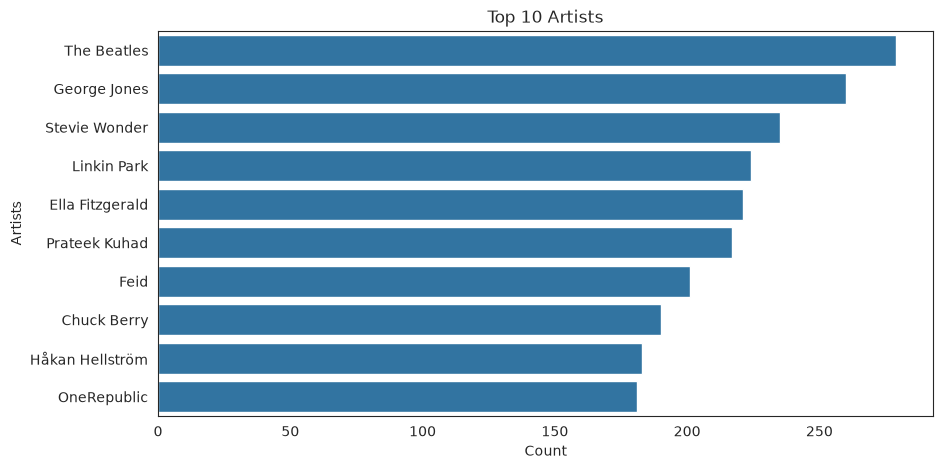

artists
The Beatles        279
George Jones       260
Stevie Wonder      235
Linkin Park        224
Ella Fitzgerald    221
Prateek Kuhad      217
Feid               201
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

In [84]:
plt.figure(figsize=(10, 5))
top_artists = df['artists'].value_counts().nlargest(10)
sns.barplot(y=top_artists.index, x=top_artists.values)
plt.title("Top 10 Artists")
plt.xlabel("Count")
plt.ylabel("Artists")
plt.show()
top_artists

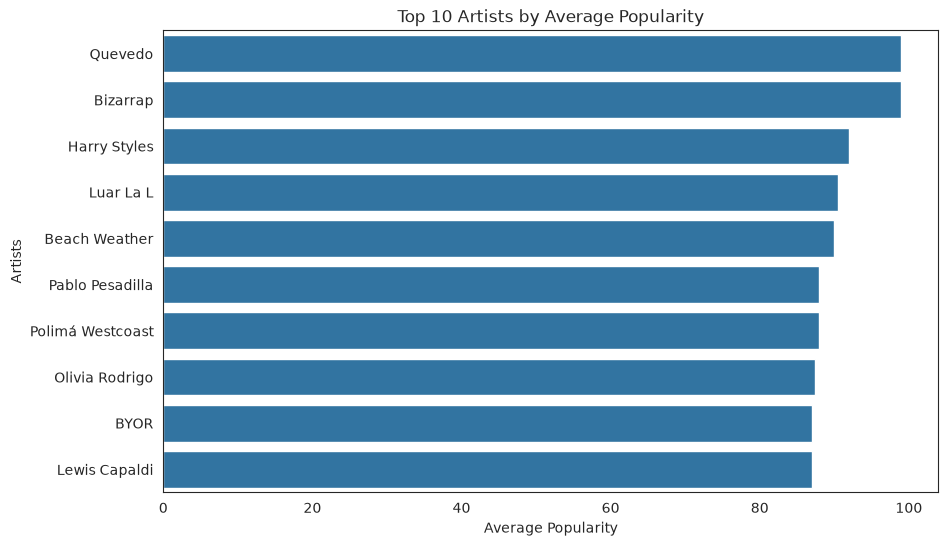

artists
Quevedo            99.000
Bizarrap           99.000
Harry Styles       92.000
Luar La L          90.500
Beach Weather      90.000
Pablo Pesadilla    88.000
Polimá Westcoast   88.000
Olivia Rodrigo     87.400
BYOR               87.000
Lewis Capaldi      87.000
Name: popularity, dtype: float64


In [85]:
copy_df = df.copy()
copy_df['artists'] = copy_df['artists'].str.split(';')
copy_df = copy_df.explode('artists')

top_artists = copy_df.groupby('artists')['popularity'].mean()
top_artists = top_artists[top_artists >= 70].sort_values(ascending=False)
top_artists_top10 = top_artists[:10]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_artists_top10.values, y=top_artists_top10.index)
plt.title('Top 10 Artists by Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Artists')
plt.show()

print(top_artists_top10)


 The top album and top track name are Halloween-themed and Christmas-themed

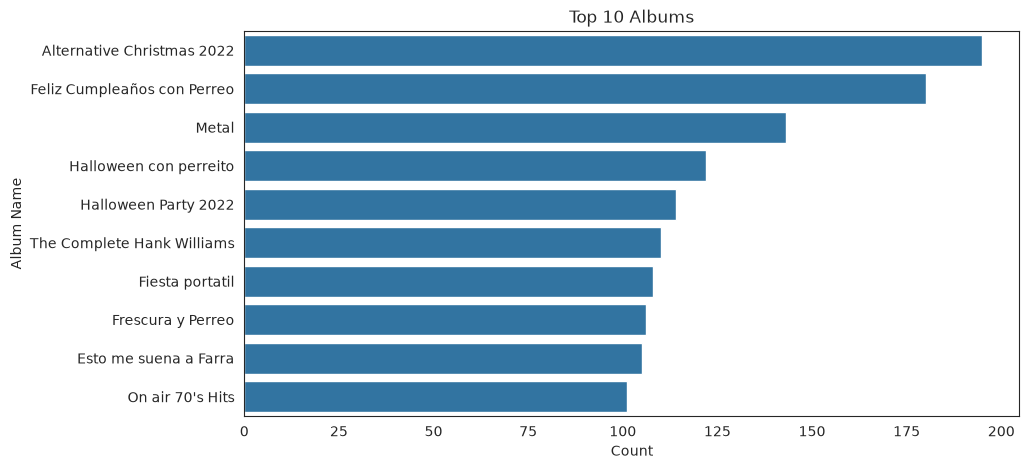

album_name
Alternative Christmas 2022     195
Feliz Cumpleaños con Perreo    180
Metal                          143
Halloween con perreito         122
Halloween Party 2022           114
The Complete Hank Williams     110
Fiesta portatil                108
Frescura y Perreo              106
Esto me suena a Farra          105
On air 70's Hits               101
Name: count, dtype: int64

In [86]:
plt.figure(figsize=(10, 5))
top_albums = df['album_name'].value_counts().nlargest(10)
sns.barplot(y=top_albums.index, x=top_albums.values)
plt.title("Top 10 Albums")
plt.xlabel("Count")
plt.ylabel("Album Name")
plt.show()
top_albums

The top 10 track genres are all popular genres, and they all appear with the same frequency

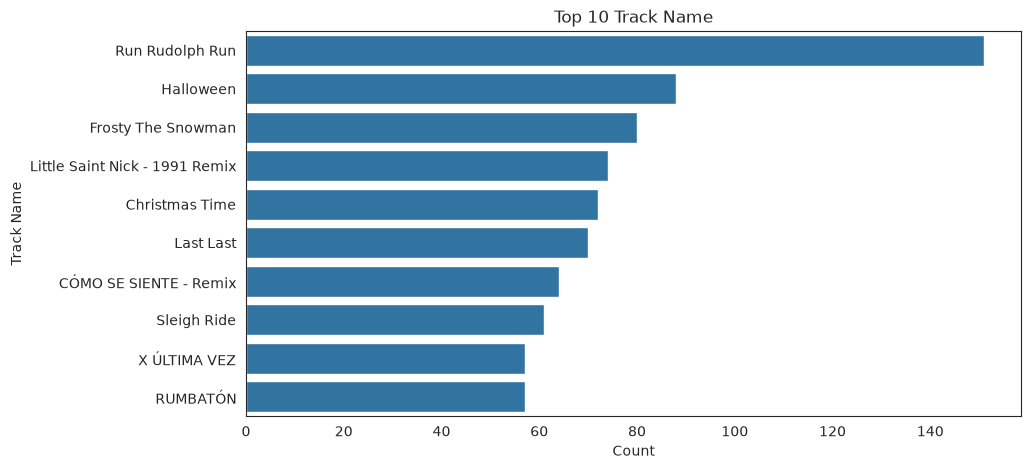

track_name
Run Rudolph Run                   151
Halloween                          88
Frosty The Snowman                 80
Little Saint Nick - 1991 Remix     74
Christmas Time                     72
Last Last                          70
CÓMO SE SIENTE - Remix             64
Sleigh Ride                        61
X ÚLTIMA VEZ                       57
RUMBATÓN                           57
Name: count, dtype: int64

In [87]:
plt.figure(figsize=(10, 5))
top_artists = df['track_name'].value_counts().nlargest(10)
sns.barplot(y=top_artists.index, x=top_artists.values)
plt.title("Top 10 Track Name")
plt.xlabel("Count")
plt.ylabel("Track Name")
plt.show()
top_artists

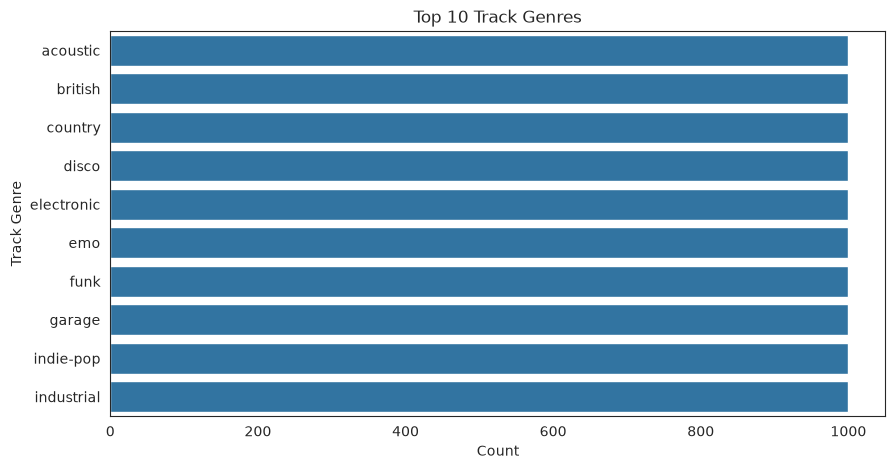

track_genre
acoustic      1000
british       1000
country       1000
disco         1000
electronic    1000
emo           1000
funk          1000
garage        1000
indie-pop     1000
industrial    1000
Name: count, dtype: int64

In [88]:
plt.figure(figsize=(10, 5))
top_genres = df['track_genre'].value_counts().nlargest(10)
sns.barplot(y=top_genres.index, x=top_genres.values)
plt.title("Top 10 Track Genres")
plt.xlabel("Count")
plt.ylabel("Track Genre")
plt.show()
top_genres

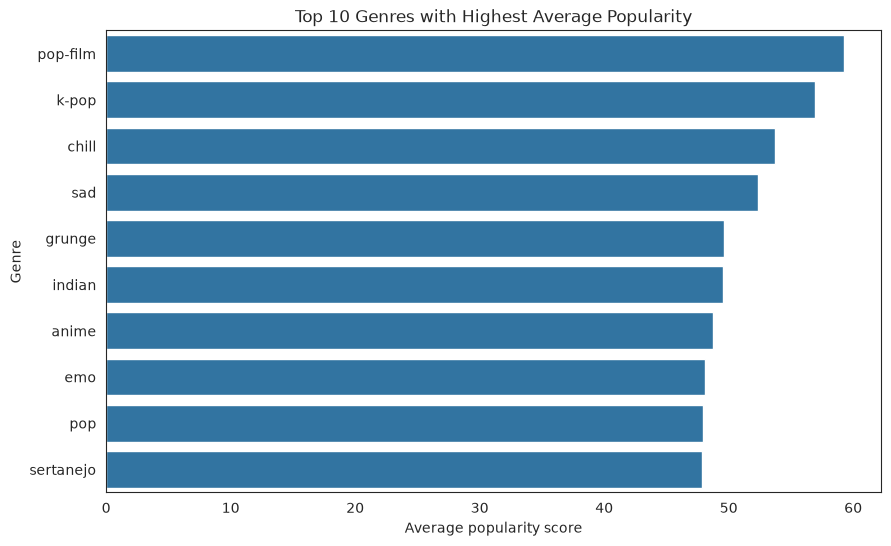

,track_genre,popularity
81,pop-film,59.280
65,k-pop,56.964
15,chill,53.705
94,sad,52.379
44,grunge,49.583
55,indian,49.529
5,anime,48.767
33,emo,48.128
80,pop,47.903
97,sertanejo,47.866


In [89]:
avg_popularity_by_genre = df.groupby('track_genre')['popularity'].mean().reset_index()
top10_popular_genres = avg_popularity_by_genre.nlargest(10, 'popularity')

plt.figure(figsize=(10, 6))
sns.barplot(x='popularity', y='track_genre', data=top10_popular_genres)
plt.title('Top 10 Genres with Highest Average Popularity')
plt.xlabel('Average popularity score')
plt.ylabel('Genre')
plt.show()

top10_popular_genres

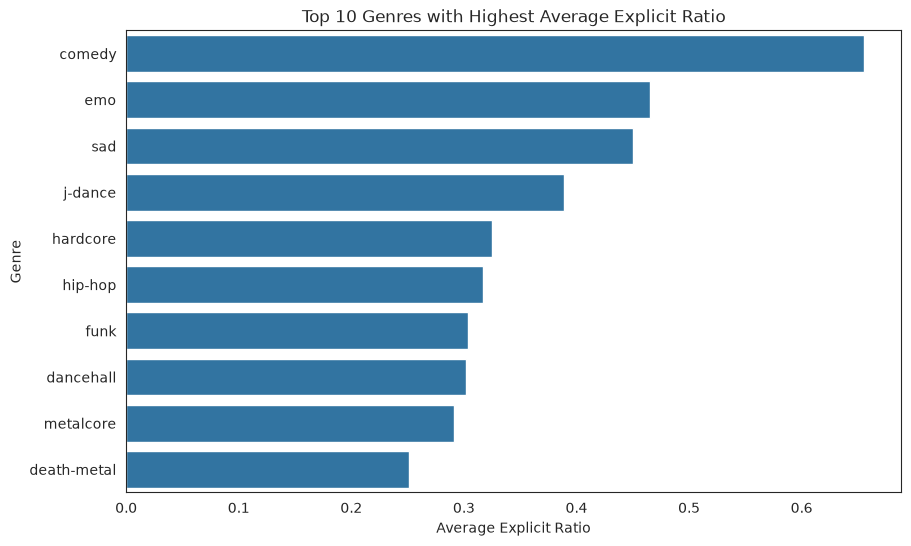

In [90]:
explicit_ratio_by_genre = df.groupby('track_genre')['explicit'].mean().reset_index()
top5_explicit_genres = explicit_ratio_by_genre.nlargest(10, 'explicit')

plt.figure(figsize=(10, 6))
sns.barplot(x='explicit', y='track_genre', data=top5_explicit_genres)
plt.title('Top 10 Genres with Highest Average Explicit Ratio')
plt.xlabel('Average Explicit Ratio')
plt.ylabel('Genre')
plt.show()

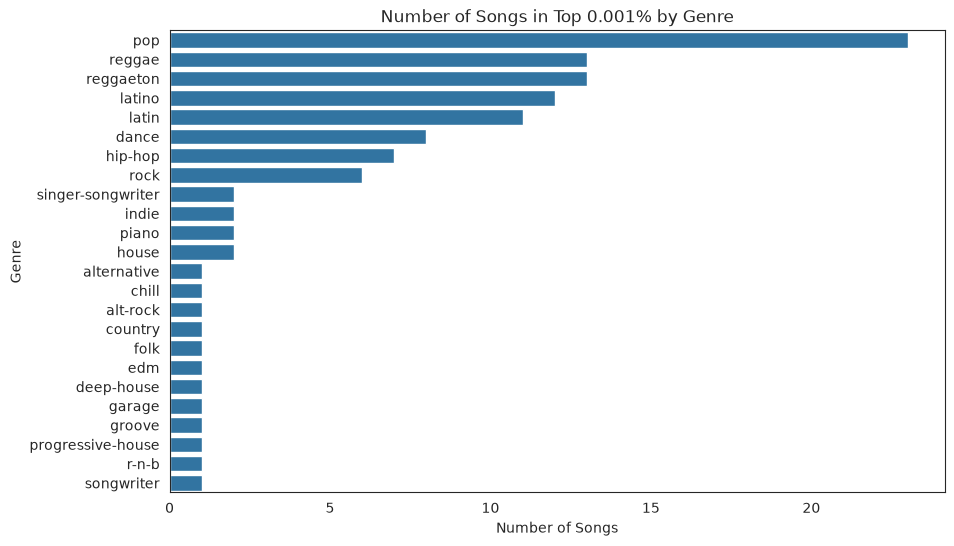

In [91]:
df_sorted = df.sort_values(by='popularity', ascending=False)
top_10_percent = df_sorted.head(int(0.001 * len(df_sorted)))
top_genres_count = top_10_percent.groupby('track_genre').size().reset_index(name='count')
top_genres_count = top_genres_count.sort_values(by='count', ascending=False)
most_common_genre = top_genres_count.loc[top_genres_count['count'].idxmax()]

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='track_genre', data=top_genres_count)
plt.title('Number of Songs in Top 0.001% by Genre')
plt.xlabel('Number of Songs')
plt.ylabel('Genre')
plt.show()

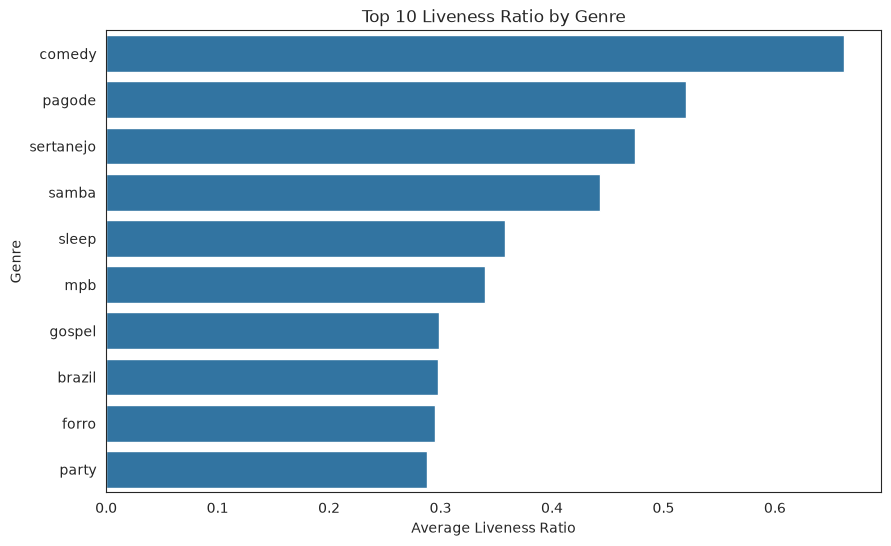

The genre with the highest liveness ratio is comedy with an average liveness ratio of 66.22%.


In [92]:
live_ratio_by_genre = df.groupby('track_genre')['liveness'].mean().reset_index()

top10_live_genres = live_ratio_by_genre.nlargest(10, 'liveness')
most_live_genre = live_ratio_by_genre.loc[live_ratio_by_genre['liveness'].idxmax()]

plt.figure(figsize=(10, 6))
sns.barplot(x='liveness', y='track_genre', data=top10_live_genres)
plt.title('Top 10 Liveness Ratio by Genre')
plt.xlabel('Average Liveness Ratio')
plt.ylabel('Genre')
plt.show()
print(f"The genre with the highest liveness ratio is {most_live_genre['track_genre']} with an average liveness ratio of {most_live_genre['liveness']:.2%}.")

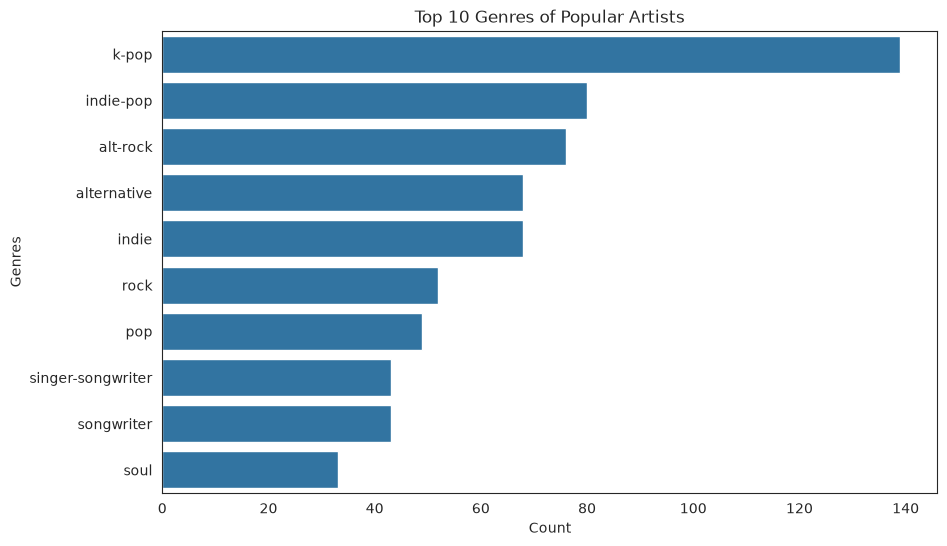

In [93]:
top_artists = copy_df.groupby('artists')['popularity'].mean()
top_artists = top_artists[top_artists >= 70].sort_values(ascending=False)
top_artists_list = top_artists.index.tolist()

genres_artists = df[df['artists'].isin(top_artists_list)]['track_genre'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=genres_artists.values, y=genres_artists.index)
plt.title('Top 10 Genres of Popular Artists')
plt.xlabel('Count')
plt.ylabel('Genres')
plt.show()


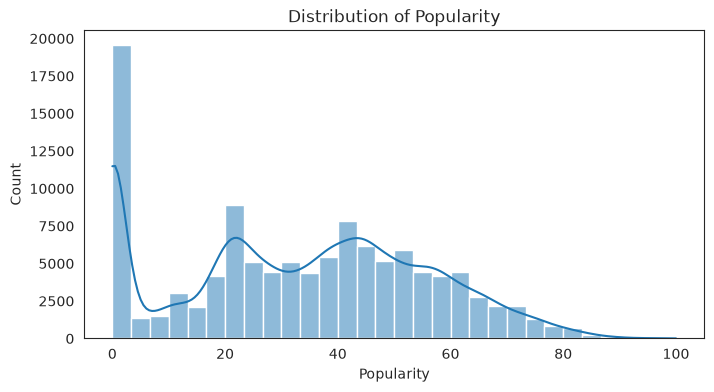

,Popularity,Count
0,0,15843
1,1,2116
2,2,1025
3,3,570
4,4,377
...,...,...
96,96,7
97,97,8
98,98,7
99,99,1


In [94]:
plt.figure(figsize=(8, 4))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title("Distribution of Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()
popularity_table = df['popularity'].value_counts().sort_index().reset_index()
popularity_table.columns = ['Popularity', 'Count']
popularity_table

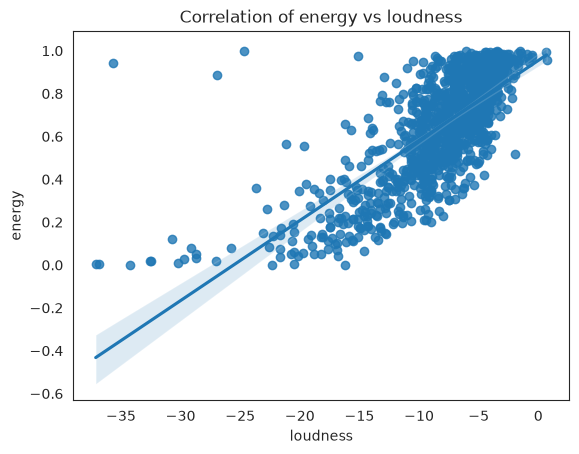

In [95]:
sample = df.sample(int(0.01 * len(df)))
sns.regplot(data=sample, y="energy", x="loudness")
plt.title("Correlation of energy vs loudness")
plt.show()

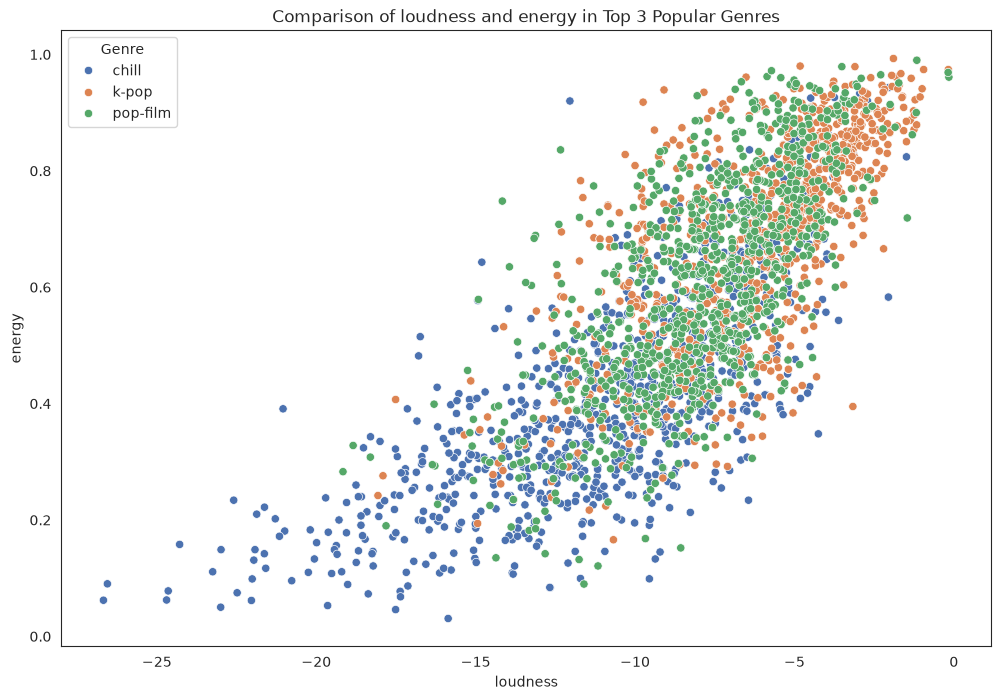

In [96]:
avg_popularity_by_genre = df.groupby('track_genre')['popularity'].mean().reset_index()
top3_popular_genres = avg_popularity_by_genre.nlargest(3, 'popularity')
top3_genre_data = df[df['track_genre'].isin(top3_popular_genres['track_genre'])]
plt.figure(figsize=(12, 8))
sns.scatterplot(x='loudness', y='energy', hue='track_genre', data=top3_genre_data, palette='deep')
plt.title('Comparison of loudness and energy in Top 3 Popular Genres')
plt.xlabel('loudness')
plt.ylabel('energy')
plt.legend(title='Genre')
plt.show()

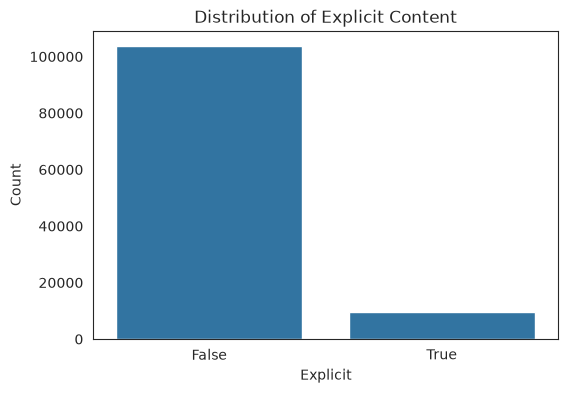

,Explicit,Count
0,False,103831
1,True,9718


In [97]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['explicit'])
plt.title("Distribution of Explicit Content")
plt.xlabel("Explicit")
plt.ylabel("Count")
plt.show()
explicit_count_table = df['explicit'].value_counts().reset_index()
explicit_count_table.columns = ['Explicit', 'Count']
explicit_count_table

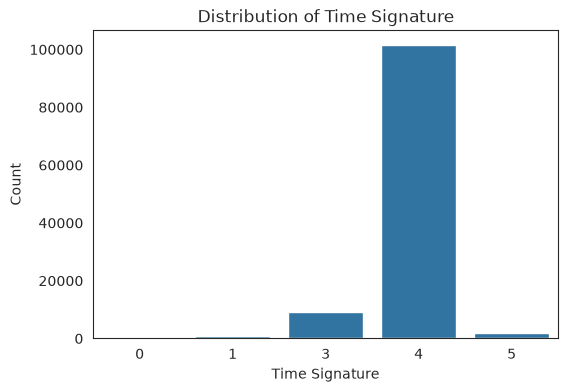

,Time Signature,Count
0,4,101486
1,3,9128
2,5,1805
3,1,967
4,0,163


In [98]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['time_signature'])
plt.title("Distribution of Time Signature")
plt.xlabel("Time Signature")
plt.ylabel("Count")
plt.show()
time_signature_count_table = df['time_signature'].value_counts().reset_index()
time_signature_count_table.columns = ['Time Signature', 'Count']
time_signature_count_table

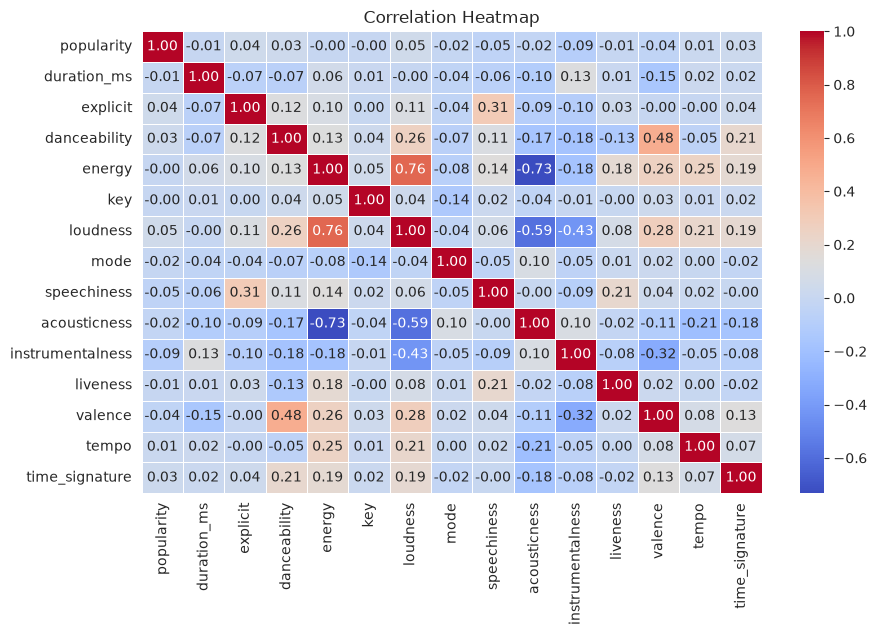

In [99]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

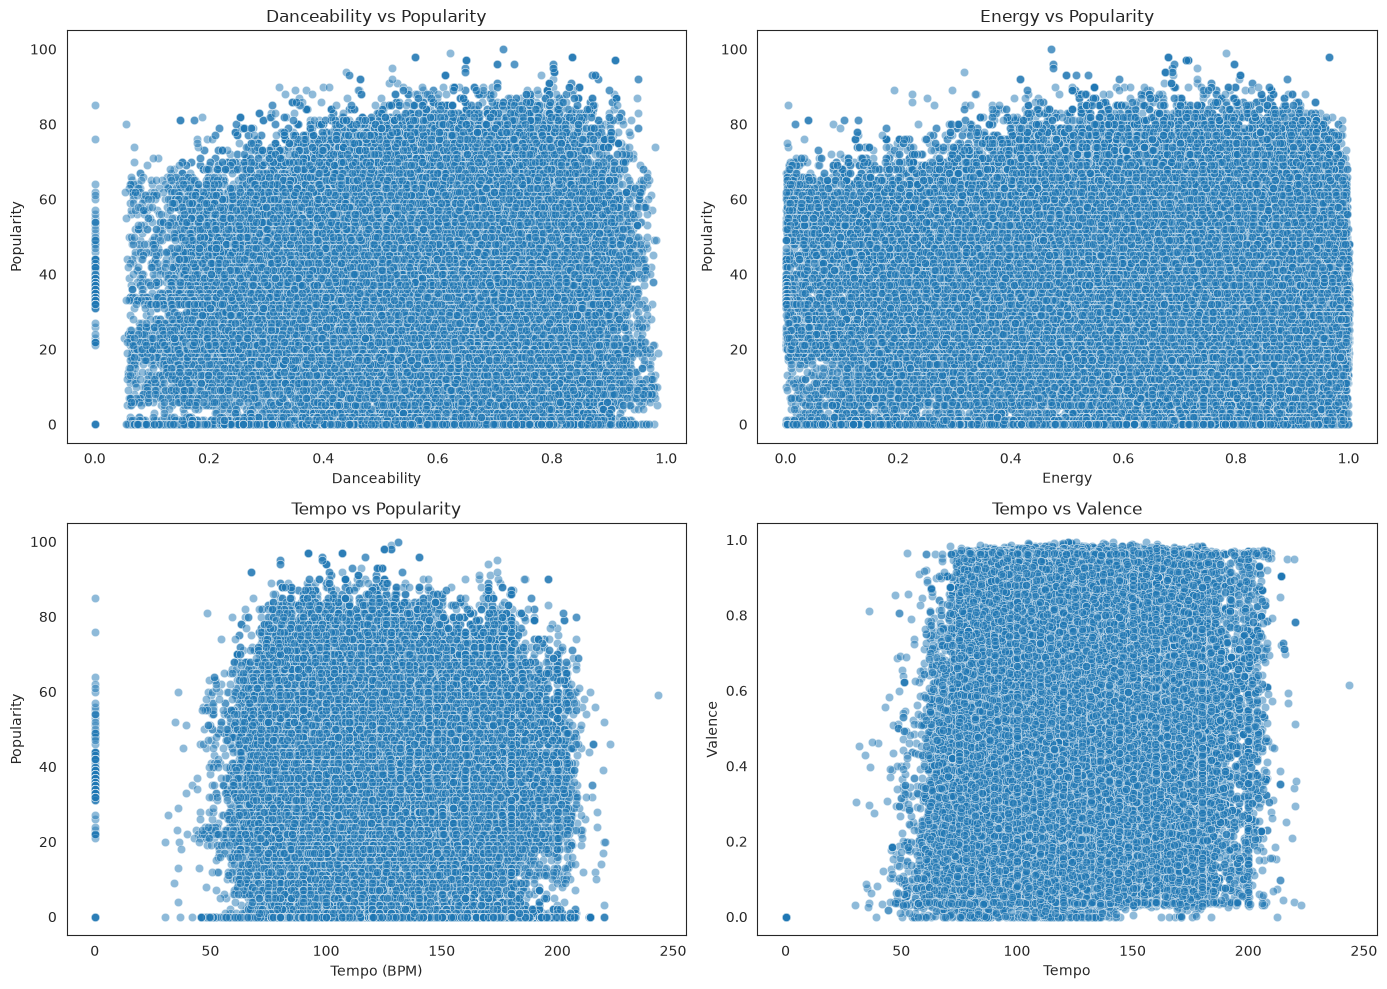

In [100]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Create 2x2 grid for 4 plots

# Danceability vs Popularity
sns.scatterplot(x=df["danceability"], y=df["popularity"], alpha=0.5, ax=axes[0, 0])
axes[0, 0].set_title("Danceability vs Popularity")
axes[0, 0].set_xlabel("Danceability")
axes[0, 0].set_ylabel("Popularity")

# Energy vs Popularity
sns.scatterplot(x=df["energy"], y=df["popularity"], alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title("Energy vs Popularity")
axes[0, 1].set_xlabel("Energy")
axes[0, 1].set_ylabel("Popularity")

# Tempo vs Popularity
sns.scatterplot(x=df["tempo"], y=df["popularity"], alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title("Tempo vs Popularity")
axes[1, 0].set_xlabel("Tempo (BPM)")
axes[1, 0].set_ylabel("Popularity")

# Tempo vs Valence
sns.scatterplot(x=df["tempo"], y=df["valence"], alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title("Tempo vs Valence")
axes[1, 1].set_xlabel("Tempo")
axes[1, 1].set_ylabel("Valence")

plt.tight_layout()
plt.show()


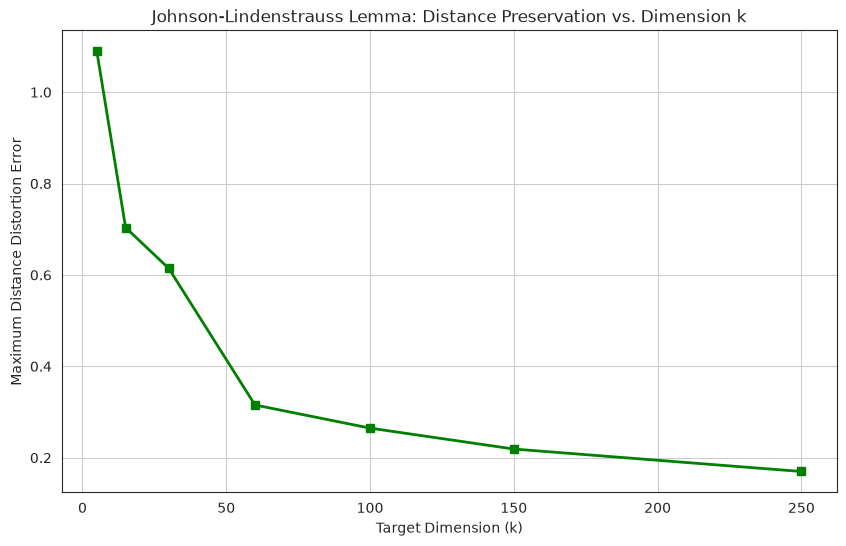

In [101]:
# Part B: Random Projection Experiment (JL Lemma)
from sklearn.metrics import pairwise_distances

# 1. Take a fixed sample of n=100 songs from the high-dimensional distribution d=300
n_jl = 100
X_high = np.random.multivariate_normal(mean, Sigma_high, size=n_jl)

# 2. Compute the original pairwise distances between all songs in the high dimension
original_distances = pairwise_distances(X_high)

# Ignore the diagonal (distance of a song to itself is 0) and keep only distances between different songs
diag_mask = ~np.eye(n_jl, dtype=bool)
orig_dist_flat = original_distances[diag_mask]

# 3. Evaluate different target dimensions (k) and observe how the error changes
k_dimensions = [5, 15, 30, 60, 100, 150, 250]
max_distortion_errors = []

for k in k_dimensions:
    # Create a Gaussian random projection matrix (normalized by sqrt(k))
    # The matrix size is (k x d)
    R = np.random.randn(k, d) / np.sqrt(k)
    
    # Project the songs to the lower dimension k (multiply the matrix by the data)
    X_low = np.dot(X_high, R.T)
    
    # Compute the new pairwise distances in the lower dimension
    low_distances = pairwise_distances(X_low)
    low_dist_flat = low_distances[diag_mask]
    
    # Compute the distance distortion ratio: new distance divided by original distance
    distortion_ratio = low_dist_flat / orig_dist_flat
    
    # Maximum error (how far the ratio deviates from 1, which represents perfect preservation)
    max_error = np.max(np.abs(distortion_ratio - 1))
    max_distortion_errors.append(max_error)

# 4. Plotting the second graph for the report
plt.figure(figsize=(10, 6))
plt.plot(k_dimensions, max_distortion_errors, marker='s', color='g', linewidth=2)
plt.xlabel('Target Dimension (k)')
plt.ylabel('Maximum Distance Distortion Error')
plt.title('Johnson-Lindenstrauss Lemma: Distance Preservation vs. Dimension k')
plt.grid(True)
plt.show()

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define the target genres we want to evaluate
target_genres = ['rock', 'pop', 'jazz', 'country', 'acoustic']

# Filter the original dataset to include only these genres
df_filtered = df[df['track_genre'].isin(target_genres)].dropna()

# 2. Define features (X) and labels (y)
X = df_filtered[features] # Musical metrics (danceability, energy, etc.)
y = df_filtered['track_genre'] # True genre labels

# 3. Split into training and testing sets - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#4.KNN on original data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("===== KNN (Original Data) =====")
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))


# 5. Initialize, train, and predict with Random Forest
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred_rf = classifier.predict(X_test)
print("===== Random Forest (Original Data) =====")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

# 6. Evaluate feature importance to see which metrics contributed most to the model
importances = classifier.feature_importances_
print("--- Feature Importances (Random Forest) ---")
for feat, imp in zip(features, importances):
    print(f"Importance of {feat}: {imp:.3f}")


===== KNN (Original Data) =====
              precision    recall  f1-score   support

    acoustic       0.69      0.81      0.75       200
     country       0.56      0.55      0.55       200
        jazz       0.79      0.67      0.72       200
         pop       0.62      0.74      0.67       199
        rock       0.60      0.47      0.52       200

    accuracy                           0.65       999
   macro avg       0.65      0.65      0.64       999
weighted avg       0.65      0.65      0.64       999

[[163   9  12  11   5]
 [ 28 110  12  23  27]
 [ 27  24 134   6   9]
 [ 11  16   3 148  21]
 [  8  38   9  52  93]]
===== Random Forest (Original Data) =====
              precision    recall  f1-score   support

    acoustic       0.73      0.92      0.81       200
     country       0.75      0.61      0.67       200
        jazz       0.88      0.79      0.83       200
         pop       0.76      0.83      0.80       199
        rock       0.78      0.73      0.75       

In [111]:
# 1. Define the target low dimension for the projection
k_target = 30

# 2. Create a Gaussian random projection matrix (k_target x d)
# We use d = 10 (the original number of features in the filtered dataset)
d_features = X.shape[1]
R_classifier = np.random.randn(k_target, d_features) / np.sqrt(k_target)

# 3. Project the data into the lower dimension
X_train_low = np.dot(X_train, R_classifier.T)
X_test_low = np.dot(X_test, R_classifier.T)

#4. KNN after JL
knn_low = KNeighborsClassifier(n_neighbors=5)
knn_low.fit(X_train_low, y_train)
y_pred_knn_low = knn_low.predict(X_test_low)
print("===== KNN (JL Projection) =====")
print(classification_report(y_test, y_pred_knn_low))
print(confusion_matrix(y_test, y_pred_knn_low))

# 4. Train a new model on the low-dimensional data
classifier_low = RandomForestClassifier(n_estimators=100, random_state=42)
classifier_low.fit(X_train_low, y_train)

# 5. Predict and evaluate performance on the low-dimensional data
y_pred_rf_low = classifier_low.predict(X_test_low)
print("===== Random Forest (JL Projection) =====")
print(classification_report(y_test, y_pred_rf_low))
print(confusion_matrix(y_test, y_pred_rf_low))

===== KNN (JL Projection) =====
              precision    recall  f1-score   support

    acoustic       0.71      0.80      0.75       200
     country       0.57      0.59      0.58       200
        jazz       0.79      0.70      0.75       200
         pop       0.62      0.74      0.68       199
        rock       0.61      0.46      0.52       200

    accuracy                           0.66       999
   macro avg       0.66      0.66      0.66       999
weighted avg       0.66      0.66      0.66       999

[[160  11  11  12   6]
 [ 25 118  13  23  21]
 [ 20  22 141   5  12]
 [ 12  15   4 148  20]
 [  8  42   9  49  92]]
===== Random Forest (JL Projection) =====
              precision    recall  f1-score   support

    acoustic       0.75      0.84      0.80       200
     country       0.67      0.57      0.61       200
        jazz       0.84      0.79      0.81       200
         pop       0.65      0.74      0.69       199
        rock       0.64      0.60      0.62       

In [119]:
# ===== XGBoost on the original (non-projected) features =====
from sklearn.preprocessing import LabelEncoder

# XGBoost's classifier needs numeric class labels, not strings like "rock"/"pop",
# so we encode the genre labels first.
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# xgb was already created earlier in the notebook:
# xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train_enc)
y_pred_xgb_enc = xgb.predict(X_test)

# Decode predictions back to genre names so the report is readable
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

print("===== XGBoost (Original Data) =====")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

# Feature importance from XGBoost
xgb_importances = xgb.feature_importances_
print("--- Feature Importances (XGBoost) ---")
for feat, imp in zip(features, xgb_importances):
    print(f"Importance of {feat}: {imp:.3f}")

===== XGBoost (Original Data) =====
              precision    recall  f1-score   support

    acoustic       0.78      0.85      0.82       200
     country       0.74      0.70      0.72       200
        jazz       0.85      0.84      0.85       200
         pop       0.77      0.80      0.79       199
        rock       0.76      0.71      0.73       200

    accuracy                           0.78       999
   macro avg       0.78      0.78      0.78       999
weighted avg       0.78      0.78      0.78       999

[[170  13  10   6   1]
 [ 12 141  12  14  21]
 [ 16   6 169   5   4]
 [ 11   9   1 159  19]
 [  8  22   6  22 142]]
--- Feature Importances (XGBoost) ---
Importance of danceability: 0.067
Importance of energy: 0.072
Importance of loudness: 0.072
Importance of speechiness: 0.075
Importance of acousticness: 0.148
Importance of instrumentalness: 0.074
Importance of liveness: 0.058
Importance of valence: 0.060
Importance of tempo: 0.051
Importance of popularity: 0.322


In [120]:
# ===== XGBoost on the JL-projected features =====
xgb_low = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)
xgb_low.fit(X_train_low, y_train_enc)
y_pred_xgb_low_enc = xgb_low.predict(X_test_low)

# Decode predictions back to genre names
y_pred_xgb_low = le.inverse_transform(y_pred_xgb_low_enc)

print("===== XGBoost (JL Projection) =====")
print(classification_report(y_test, y_pred_xgb_low))
print(confusion_matrix(y_test, y_pred_xgb_low))

===== XGBoost (JL Projection) =====
              precision    recall  f1-score   support

    acoustic       0.75      0.84      0.79       200
     country       0.63      0.54      0.58       200
        jazz       0.84      0.79      0.81       200
         pop       0.65      0.74      0.69       199
        rock       0.63      0.59      0.61       200

    accuracy                           0.70       999
   macro avg       0.70      0.70      0.70       999
weighted avg       0.70      0.70      0.70       999

[[169  10   8  10   3]
 [ 21 107  18  21  33]
 [ 20   6 157  10   7]
 [  8  14   2 147  28]
 [  8  32   3  38 119]]


In [121]:
def get_metrics(name, y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted"
    )

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": p,
        "Recall": r,
        "F1": f1
    }

results = pd.DataFrame([
    get_metrics("KNN (Original)", y_test, y_pred_knn),
    get_metrics("RF (Original)", y_test, y_pred_rf),
    get_metrics("XGBoost (Original)", y_test, y_pred_xgb),
    get_metrics("KNN (JL)", y_test, y_pred_knn_low),
    get_metrics("RF (JL)", y_test, y_pred_rf_low),
    get_metrics("XGBoost (JL)", y_test, y_pred_xgb_low)   
])

print(results)

                Model  Accuracy  Precision  Recall    F1
0      KNN (Original)     0.649      0.650   0.649 0.645
1       RF (Original)     0.775      0.779   0.775 0.772
2  XGBoost (Original)     0.782      0.781   0.782 0.781
3            KNN (JL)     0.660      0.661   0.660 0.656
4             RF (JL)     0.709      0.709   0.709 0.707
5        XGBoost (JL)     0.700      0.699   0.700 0.697
